# CORUM Ground Truth Collection
Build protein complex co-membership ground truth from the CORUM database for the protein embedding benchmark.

CORUM provides experimentally verified mammalian protein complexes. Co-membership in a complex is the strongest form of protein-protein association: these proteins physically interact and must be co-expressed.

Same matrix structure as KEGG and Reactome notebooks.

In [4]:
from _common import CACHE, FASTA, fetch, require_manual  # noqa: F401
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
from matplotlib.patches import Patch

# 1. Load and inspect the CORUM data

In [5]:
corum_path = require_manual(
    'corum_humanComplexes.txt',
    'https://mips.helmholtz-muenchen.de/corum/download',
    'Take the human complexes table from the CORUM download page.',
)
df_corum = pd.read_csv(corum_path, sep='\t')

print(f"Total complexes: {len(df_corum)}")
print(f"Columns: {list(df_corum.columns)}")
df_corum.head(3)

Total complexes: 5513
Columns: ['complex_id', 'complex_name', 'synonyms', 'organism', 'cell_line', 'pmid', 'comment_complex', 'comment_members', 'comment_disease', 'comment_drug', 'comment_drug_formal', 'subunits_uniprot_id', 'subunits_gene_name', 'subunits_gene_name_synonyms', 'subunits_protein_name', 'subunits_proteinname_synonyms', 'subunits_organism', 'subunits_drugs', 'subunits_mims', 'subunits_stoechiometrie', 'purification_methods', 'functions_evi', 'functions_pmid', 'functions_go_id', 'functions_go_name', 'functions_go_ontology', 'fcgs_description', 'fcgs_id', 'fcgs_name', 'fcgs_category_id', 'fcgs_category_name', 'fcgs_go_id', 'fcgs_go_name', 'fcgs_go_ontology']


,complex_id,complex_name,synonyms,organism,cell_line,pmid,comment_complex,comment_members,comment_disease,comment_drug,...,functions_go_name,functions_go_ontology,fcgs_description,fcgs_id,fcgs_name,fcgs_category_id,fcgs_category_name,fcgs_go_id,fcgs_go_name,fcgs_go_ontology
0,1,BCL6-HDAC4 complex,NaN,Human,U2OS osteosarcoma-derived UTA-L cells,11929873,Transcriptional repression by BCL6 is thought ...,NaN,NaN,NaN,...,histone deacetylase activity;nucleus;DNA topol...,molecular_function;cellular_component;biologic...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,BCL6-HDAC5 complex,NaN,Human,U2OS osteosarcoma-derived UTA-L cells,11929873,Transcriptional repression by BCL6 is thought ...,NaN,NaN,NaN,...,histone deacetylase activity;nucleus;DNA topol...,molecular_function;cellular_component;biologic...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,BCL6-HDAC7 complex,NaN,Human,U2OS osteosarcoma-derived UTA-L cells,11929873,Transcriptional repression by BCL6 is thought ...,NaN,NaN,NaN,...,histone deacetylase activity;nucleus;DNA topol...,molecular_function;cellular_component;biologic...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Inspect the key column: subunits_uniprot_id
print("Sample subunits_uniprot_id values:")
for i, row in df_corum.head(10).iterrows():
    print(f"  Complex {row['complex_id']} ({row['complex_name']}):")
    print(f"    {row['subunits_uniprot_id']}")

Sample subunits_uniprot_id values:
  Complex 1 (BCL6-HDAC4 complex):
    P41182;P56524
  Complex 2 (BCL6-HDAC5 complex):
    P41182;Q9UQL6
  Complex 3 (BCL6-HDAC7 complex):
    P41182;Q8WUI4
  Complex 4 (Multisubunit ACTR coactivator complex):
    Q92793;Q09472;Q92831;Q9Y6Q9
  Complex 10 (Condensin I complex):
    Q15021;Q9BPX3;Q15003;O95347;Q9NTJ3
  Complex 11 (BLOC-3 (biogenesis of lysosome-related organelles complex 3)):
    Q92902;Q9NQG7
  Complex 12 (BLOC-2 (biogenesis of lysosome-related organelles complex 2)):
    Q969F9;Q9UPZ3;Q86YV9
  Complex 13 (CDS1-MUS81 complex):
    Q92903;Q96NY9
  Complex 15 (NCOR complex):
    Q92828;Q13227;O15379;O75376;O60907;Q9BZK7
  Complex 23 (BLOC-1 (biogenesis of lysosome-related organelles complex 1)):
    P78537;Q6QNY1;Q6QNY0;Q9NUP1;Q8TDH9;Q9UL45;Q96EV8;O95295


In [7]:
# Check for any issues
print(f"Rows with missing subunits: {df_corum['subunits_uniprot_id'].isna().sum()}")
print(f"Unique organisms: {df_corum['organism'].unique()}")
print(f"Organism distribution:")
print(df_corum['organism'].value_counts())

Rows with missing subunits: 0
Unique organisms: ['Human']
Organism distribution:
organism
Human    5513
Name: count, dtype: int64


# 2. Parse complexes into complex → protein sets

In [8]:
# Parse subunits_uniprot_id (semicolon-separated) into sets
# Filter for Human complexes only (should already be human-only file, but just in case)
complex_to_proteins = {}
protein_to_complexes = defaultdict(set)

for _, row in df_corum.iterrows():
    complex_id = row['complex_id']
    complex_name = row['complex_name']
    subunits_raw = row['subunits_uniprot_id']
    
    if pd.isna(subunits_raw):
        continue
    
    # Split semicolon-separated UniProt IDs and clean
    subunits = set()
    for uid in str(subunits_raw).split(';'):
        uid = uid.strip()
        if uid:  # skip empty strings
            subunits.add(uid)
    
    if len(subunits) >= 2:  # a complex needs at least 2 subunits
        key = f"{complex_id} {complex_name}"
        complex_to_proteins[key] = subunits
        for uid in subunits:
            protein_to_complexes[uid].add(key)

protein_to_complexes = dict(protein_to_complexes)

print(f"Complexes with ≥2 subunits: {len(complex_to_proteins)}")
print(f"Unique proteins: {len(protein_to_complexes)}")

Complexes with ≥2 subunits: 5226
Unique proteins: 5197


In [9]:
# Complex size distribution
sizes = sorted([len(p) for p in complex_to_proteins.values()])
print(f"Complex size distribution:")
print(f"  Min: {sizes[0]}, Median: {sizes[len(sizes)//2]}, Mean: {np.mean(sizes):.1f}, Max: {sizes[-1]}")

print(f"\nComplexes per protein:")
cpx_per_prot = sorted([len(v) for v in protein_to_complexes.values()])
print(f"  Min: {cpx_per_prot[0]}, Median: {cpx_per_prot[len(cpx_per_prot)//2]}, "
      f"Mean: {np.mean(cpx_per_prot):.1f}, Max: {cpx_per_prot[-1]}")

print(f"\n5 largest complexes:")
for cpx, prots in sorted(complex_to_proteins.items(), key=lambda x: len(x[1]), reverse=True)[:5]:
    print(f"  {cpx}: {len(prots)} subunits")

print(f"\n5 smallest complexes:")
for cpx, prots in sorted(complex_to_proteins.items(), key=lambda x: len(x[1]))[:5]:
    print(f"  {cpx}: {len(prots)} subunits")

Complex size distribution:
  Min: 2, Median: 2, Mean: 3.5, Max: 129

Complexes per protein:
  Min: 1, Median: 2, Mean: 3.5, Max: 108

5 largest complexes:
  8391 Spliceosome, E complex: 129 subunits
  8372 Spliceosome, A complex: 112 subunits
  3055 Nop56p-associated pre-rRNA complex: 104 subunits
  306 Ribosome, cytoplasmic: 80 subunits
  1181 C complex spliceosome: 80 subunits

5 smallest complexes:
  1 BCL6-HDAC4 complex: 2 subunits
  2 BCL6-HDAC5 complex: 2 subunits
  3 BCL6-HDAC7 complex: 2 subunits
  11 BLOC-3 (biogenesis of lysosome-related organelles complex 3): 2 subunits
  13 CDS1-MUS81 complex: 2 subunits


# 3. Evaluate label thresholds

Same analysis as KEGG/Reactome: how does the balance shift with different thresholds for shared complex membership?

CORUM complexes are smaller and more specific than pathways, so sharing even 1 complex is a strong signal.

In [10]:
# Build protein → set of complex IDs for the dot product approach
protein_to_cpx_set = defaultdict(set)
for cpx_key, prots in complex_to_proteins.items():
    cpx_id = cpx_key.split(' ')[0]  # just the numeric ID for efficiency
    for p in prots:
        protein_to_cpx_set[p].add(cpx_id)
protein_to_cpx_set = dict(protein_to_cpx_set)

# Compute shared complex counts using dot product
corum_protein_list = sorted(protein_to_cpx_set.keys())
all_complexes_sorted = sorted(set().union(*protein_to_cpx_set.values()))
cpx_to_idx = {c: i for i, c in enumerate(all_complexes_sorted)}

n_corum = len(corum_protein_list)
print(f"CORUM proteins: {n_corum}")
print(f"CORUM complexes: {len(all_complexes_sorted)}")
print(f"Unique pairs: {n_corum * (n_corum - 1) // 2:,}")

membership = np.zeros((n_corum, len(all_complexes_sorted)), dtype=np.float32)
for i, prot in enumerate(corum_protein_list):
    for cpx in protein_to_cpx_set[prot]:
        membership[i, cpx_to_idx[cpx]] = 1.0

print(f"Membership matrix: {membership.shape}")
print(f"Computing shared complex counts...")
shared_counts = membership @ membership.T
print("Done!")

CORUM proteins: 5197
CORUM complexes: 5226
Unique pairs: 13,501,806
Membership matrix: (5197, 5226)
Computing shared complex counts...
Done!


In [11]:
# Shared complex count distribution
upper_tri = shared_counts[np.triu_indices(n_corum, k=1)]
total_pairs = len(upper_tri)

print(f"Total evaluable pairs (both in CORUM): {total_pairs:,}")
print(f"Pairs sharing 0 complexes: {np.sum(upper_tri == 0):,}")
print(f"\nShared complex count distribution:")
for i in range(min(20, int(upper_tri.max()) + 1)):
    count = np.sum(upper_tri == i)
    if count > 0:
        print(f"  {i:>3} shared complexes: {count:>12,} pairs ({count/total_pairs*100:.2f}%)")

print(f"\n  Max shared complexes: {int(upper_tri.max())}")

Total evaluable pairs (both in CORUM): 13,501,806
Pairs sharing 0 complexes: 13,453,423

Shared complex count distribution:
    0 shared complexes:   13,453,423 pairs (99.64%)
    1 shared complexes:       33,519 pairs (0.25%)
    2 shared complexes:        9,076 pairs (0.07%)
    3 shared complexes:        2,990 pairs (0.02%)
    4 shared complexes:        1,246 pairs (0.01%)
    5 shared complexes:          608 pairs (0.00%)
    6 shared complexes:          299 pairs (0.00%)
    7 shared complexes:          189 pairs (0.00%)
    8 shared complexes:          111 pairs (0.00%)
    9 shared complexes:           70 pairs (0.00%)
   10 shared complexes:           51 pairs (0.00%)
   11 shared complexes:           37 pairs (0.00%)
   12 shared complexes:           46 pairs (0.00%)
   13 shared complexes:           31 pairs (0.00%)
   14 shared complexes:           19 pairs (0.00%)
   15 shared complexes:           16 pairs (0.00%)
   16 shared complexes:           11 pairs (0.00%)
   17 sh

# 4. Build the ground truth matrix

- `1` = positive (share ≥ 1 complex, both in CORUM)
- `0` = negative (share 0 complexes, both in CORUM)
- `NaN` = at least one protein not in any CORUM complex

Proteins ordered alphabetically — same order as KEGG and Reactome matrices.

## 4.1 Load protein accessions

In [12]:
from Bio import SeqIO

fasta_path = FASTA

protein_sequences = {}
for record in SeqIO.parse(fasta_path, 'fasta'):
    protein_id = record.id.split('|')[1]
    protein_sequences[protein_id] = str(record.seq)

all_proteins = list(protein_sequences.keys())
all_proteins_sorted = sorted(all_proteins)
n = len(all_proteins_sorted)
prot_to_idx = {p: i for i, p in enumerate(all_proteins_sorted)}

print(f"Total proteins: {n}")
print(f"Matrix shape: {n} x {n}")

Total proteins: 20372
Matrix shape: 20372 x 20372


In [13]:
# Check overlap between CORUM proteins and our FASTA
corum_set = set(protein_to_cpx_set.keys())
fasta_set = set(all_proteins)

in_both = corum_set & fasta_set
corum_only = corum_set - fasta_set

print(f"CORUM proteins: {len(corum_set)}")
print(f"In both CORUM and FASTA: {len(in_both)}")
print(f"In CORUM only (not in FASTA): {len(corum_only)}")

if corum_only:
    print(f"\nSample CORUM-only IDs: {sorted(corum_only)[:10]}")

CORUM proteins: 5197
In both CORUM and FASTA: 5024
In CORUM only (not in FASTA): 173

Sample CORUM-only IDs: ['A1Z199', 'A6NFQ2-2', 'A9UF07', 'B4DGM9', 'D9YZV4', 'E9PGT3', 'O00187-2', 'O00571-2', 'O15350-1', 'O15519-1']


## 4.2 Build the matrix

In [14]:
# Initialize all NaN
corum_matrix = np.full((n, n), np.nan, dtype=np.float32)

# Filter to CORUM proteins in our FASTA vocabulary
corum_in_fasta = sorted([p for p in protein_to_cpx_set.keys() if p in prot_to_idx])
corum_indices = np.array([prot_to_idx[p] for p in corum_in_fasta])

print(f"CORUM proteins in our vocabulary: {len(corum_indices)} / {n}")

# Set all CORUM×CORUM pairs to 0 (negative by default)
corum_matrix[np.ix_(corum_indices, corum_indices)] = 0.0
print("Set all CORUM×CORUM pairs to 0 (negative)")

CORUM proteins in our vocabulary: 5024 / 20372
Set all CORUM×CORUM pairs to 0 (negative)


In [15]:
# Set positives: pairs sharing ≥ 1 complex
membership_fasta = np.zeros((len(corum_in_fasta), len(all_complexes_sorted)), dtype=np.float32)
for i, prot in enumerate(corum_in_fasta):
    for cpx in protein_to_cpx_set[prot]:
        membership_fasta[i, cpx_to_idx[cpx]] = 1.0

shared = membership_fasta @ membership_fasta.T

# Map to full matrix indices
full_indices = np.array([prot_to_idx[p] for p in corum_in_fasta])

# Set positives (exclude diagonal)
pos_i, pos_j = np.where(shared >= 1)
mask = pos_i != pos_j
pos_i, pos_j = pos_i[mask], pos_j[mask]

corum_matrix[full_indices[pos_i], full_indices[pos_j]] = 1.0
print(f"Set {len(pos_i):,} positive entries (both directions)")

Set 95,884 positive entries (both directions)


In [16]:
# Set diagonal to NaN
np.fill_diagonal(corum_matrix, np.nan)

# Verify counts
upper = corum_matrix[np.triu_indices(n, k=1)]
n_pos = np.nansum(upper == 1)
n_neg = np.nansum(upper == 0)
n_nan = np.sum(np.isnan(upper))

print(f"Upper triangle counts:")
print(f"  Positive (1): {int(n_pos):>12,}")
print(f"  Negative (0): {int(n_neg):>12,}")
print(f"  NaN:          {int(n_nan):>12,}")
print(f"  Total:        {len(upper):>12,}")
print(f"\n  Pos/Neg ratio: {n_pos/n_neg:.6f}")
print(f"  Matrix is symmetric: {np.allclose(corum_matrix, corum_matrix.T, equal_nan=True)}")

Upper triangle counts:
  Positive (1):       47,942
  Negative (0):   12,569,834
  NaN:           194,881,230
  Total:         207,499,006

  Pos/Neg ratio: 0.003814
  Matrix is symmetric: True


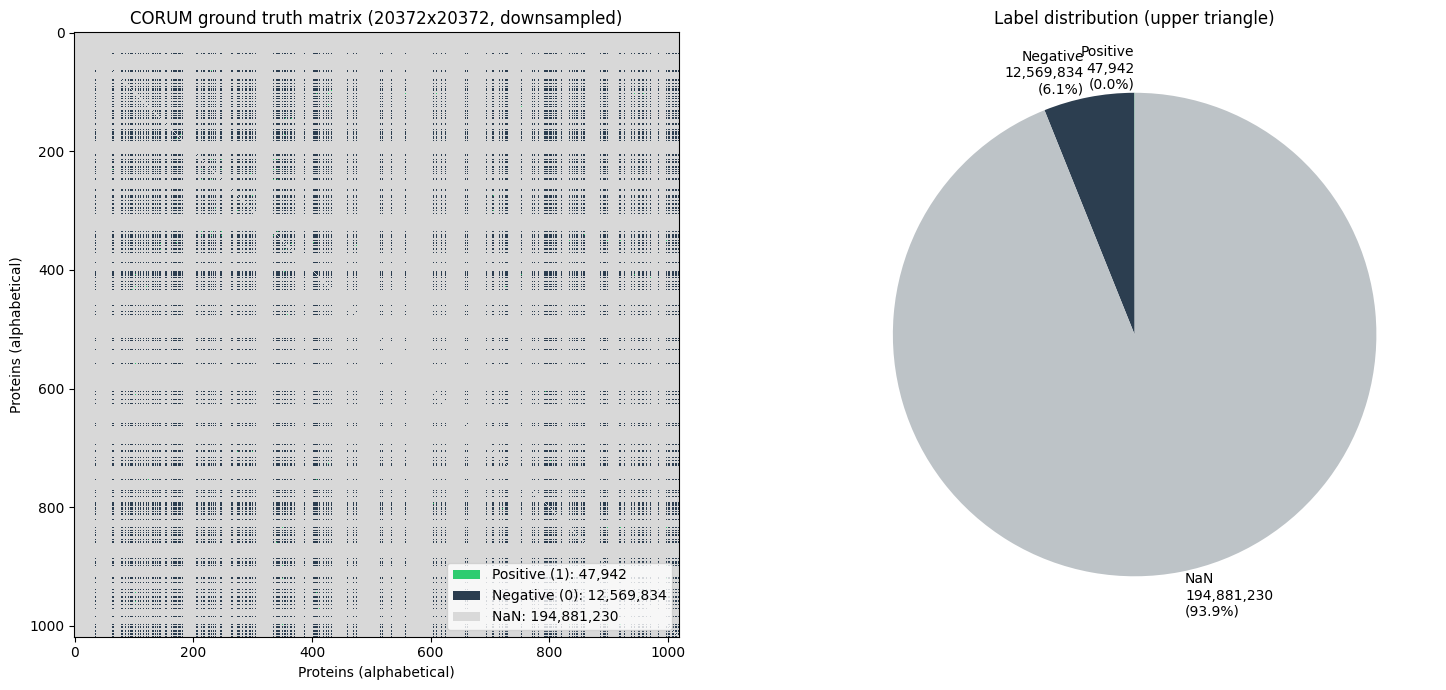

In [17]:
# Visualize the matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

step = max(1, n // 1000)
display_matrix = corum_matrix[::step, ::step]

rgb = np.zeros((*display_matrix.shape, 3), dtype=np.float32)
nan_mask = np.isnan(display_matrix)
neg_mask = display_matrix == 0
pos_mask = display_matrix == 1

rgb[nan_mask] = [0.85, 0.85, 0.85]
rgb[neg_mask] = [0.17, 0.24, 0.31]
rgb[pos_mask] = [0.18, 0.80, 0.44]

axes[0].imshow(rgb, aspect='equal', interpolation='nearest')
axes[0].set_title(f"CORUM ground truth matrix ({n}x{n}, downsampled)", fontsize=12)
axes[0].set_xlabel("Proteins (alphabetical)")
axes[0].set_ylabel("Proteins (alphabetical)")

legend_elements = [
    Patch(facecolor=[0.18, 0.80, 0.44], label=f'Positive (1): {int(n_pos):,}'),
    Patch(facecolor=[0.17, 0.24, 0.31], label=f'Negative (0): {int(n_neg):,}'),
    Patch(facecolor=[0.85, 0.85, 0.85], label=f'NaN: {int(n_nan):,}'),
]
axes[0].legend(handles=legend_elements, loc='lower right')

sizes_plot = [int(n_pos), int(n_neg), int(n_nan)]
labels = [f'Positive\n{int(n_pos):,}\n({n_pos/len(upper)*100:.1f}%)',
          f'Negative\n{int(n_neg):,}\n({n_neg/len(upper)*100:.1f}%)',
          f'NaN\n{int(n_nan):,}\n({n_nan/len(upper)*100:.1f}%)']
colors = ['#2ecc71', '#2c3e50', '#bdc3c7']

axes[1].pie(sizes_plot, labels=labels, colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Label distribution (upper triangle)', fontsize=12)

plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path
from omicsfm.attention import GT_DIR_DEFAULT, save_ppi_ground_truth

# save_ppi_ground_truth stores only the positives and the covered-protein
# universe (~36x smaller, reconstructs the dense matrix exactly) and will
# not replace an existing file: published results are pinned to the
# matrices in reference/, and these source databases change over time.
# save
import os

save_ppi_ground_truth(
    path=Path(GT_DIR_DEFAULT) / "corum_ground_truth_matrix.npz",
    matrix=corum_matrix,
    overwrite=False,   # True re-pins the published matrix; every result
                       # and figure derived from it must be regenerated too
)

# Protein order file (same as KEGG/Reactome — alphabetical)
with open("corum_ground_truth_proteins.tsv", "w") as f:
    f.write("idx\tprotein\n")
    for i, p in enumerate(all_proteins_sorted):
        f.write(f"{i}\t{p}\n")

npz_size = os.path.getsize("corum_ground_truth_matrix.npz") / 1e6
print(f"Saved corum_ground_truth_matrix.npz ({npz_size:.1f} MB)")
print(f"Saved corum_ground_truth_proteins.tsv")
print(f"\nTo load later:")
print(f"  matrix = np.load('corum_ground_truth_matrix.npz')['matrix']")
print(f"  # shape ({n}, {n}), values: 0, 1, NaN")

Saved corum_ground_truth_matrix.npz (22.6 MB)
Saved corum_ground_truth_proteins.tsv

To load later:
  matrix = np.load('corum_ground_truth_matrix.npz')['matrix']
  # shape (20372, 20372), values: 0, 1, NaN
